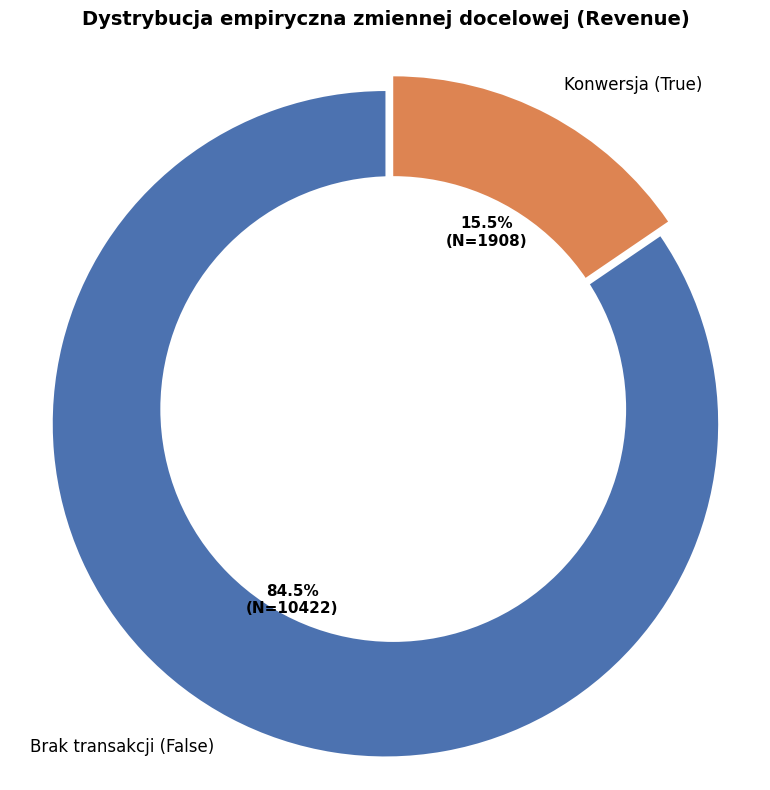

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('online_shoppers_intention.csv')
revenue_counts = df['Revenue'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
labels = ['Brak transakcji (False)', 'Konwersja (True)']
colors = ['#4C72B0', '#DD8452']
explode = (0.05, 0) # Delikatna separacja klasy większościowej

def func_format(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n(N={absolute})"

wedges, texts, autotexts = ax.pie(
    revenue_counts, 
    labels=labels, 
    autopct=lambda pct: func_format(pct, revenue_counts),
    startangle=90, 
    colors=colors, 
    explode=explode,
    textprops=dict(color="black", fontsize=12)
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax.axis('equal')  
plt.title('Dystrybucja empiryczna zmiennej docelowej (Revenue)', fontsize=14, pad=20, weight='bold')
plt.setp(autotexts, size=11, weight="bold", color="black")

plt.tight_layout()
# Zapis na dysk
plt.savefig('class_imbalance.png', dpi=300, transparent=True)
plt.show()

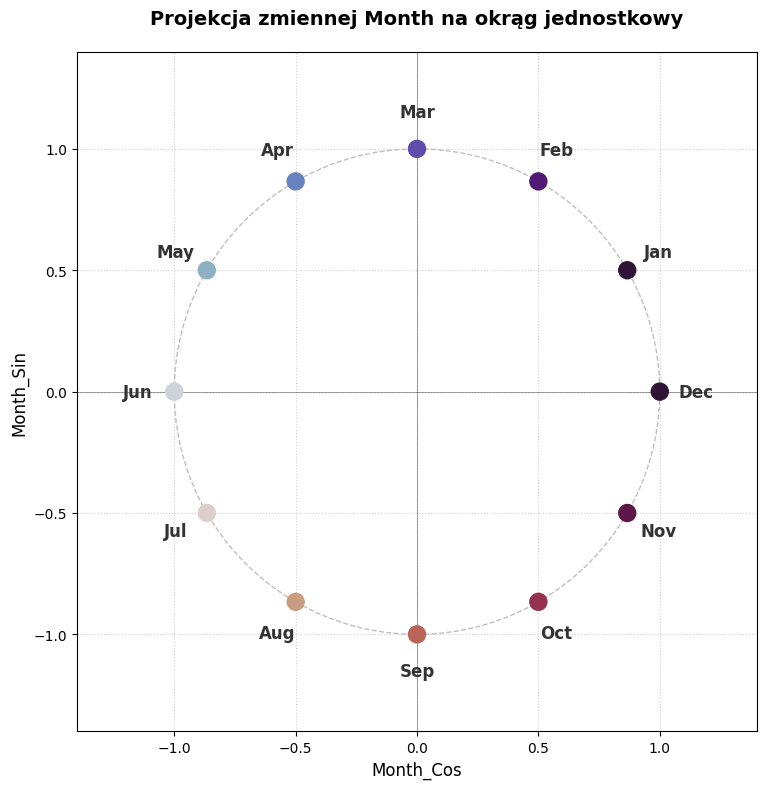

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generowanie wektorów dla 12 miesięcy
months_num = np.arange(1, 13)
months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

sin_feat = np.sin(2 * np.pi * months_num / 12)
cos_feat = np.cos(2 * np.pi * months_num / 12)

fig, ax = plt.subplots(figsize=(8, 8))

circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.5)
ax.add_patch(circle)

scatter = ax.scatter(cos_feat, sin_feat, c=months_num, cmap='twilight_shifted', s=150, zorder=5)

for i, txt in enumerate(months_labels):
    offset_x = 1.15 * cos_feat[i]
    offset_y = 1.15 * sin_feat[i]
    ax.text(offset_x, offset_y, txt, fontsize=12, fontweight='bold', 
            ha='center', va='center', color='#333333')


ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='black', linewidth=0.5, alpha=0.5)
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect('equal')

plt.title('Projekcja zmiennej Month na okrąg jednostkowy', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Month_Cos', fontsize=12)
plt.ylabel('Month_Sin', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
# Zapis na dysk
plt.savefig('cyclic_encoding.png', dpi=300, transparent=True)
plt.show()

C:\Users\janas\AppData\Local\Temp\ipykernel_31336\3786356937.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\janas\AppData\Local\Temp\ipykernel_31336\3786356937.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Brak transakcji (False)', 'Konwersja (True)'], fontsize=11)


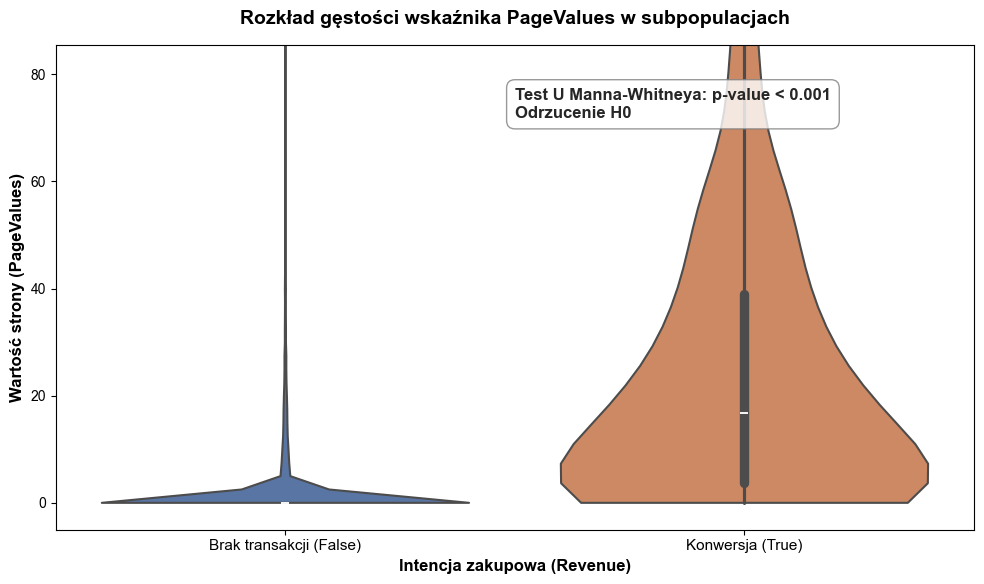

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('online_shoppers_intention.csv')

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Generowanie wykresu skrzypcowego z nałożonym wykresem pudełkowym
# Parametr cut=0 zapobiega rysowaniu estymacji gęstości (KDE) poniżej zera
sns.violinplot(
    x='Revenue', 
    y='PageValues', 
    data=df, 
    ax=ax, 
    palette=['#4C72B0', '#DD8452'], 
    inner="box", 
    cut=0, 
    linewidth=1.5
)

# ograniczenie osi Y do 99. percentyla w celu odcięcia ekstremalnych outliers
y_max = df['PageValues'].quantile(0.99)
ax.set_ylim(-5, y_max)

ax.text(
    0.5, 0.85, 
    "Test U Manna-Whitneya: p-value < 0.001\nOdrzucenie H0", 
    transform=ax.transAxes, 
    fontsize=12, 
    fontweight='bold', 
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5')
)

ax.set_title('Rozkład gęstości wskaźnika PageValues w subpopulacjach', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Intencja zakupowa (Revenue)', fontsize=12, fontweight='bold')
ax.set_ylabel('Wartość strony (PageValues)', fontsize=12, fontweight='bold')
ax.set_xticklabels(['Brak transakcji (False)', 'Konwersja (True)'], fontsize=11)

plt.tight_layout()
# Zapis na dysk
plt.savefig('slide_9_violin_pagevalues.png', dpi=300, transparent=True)
plt.show()

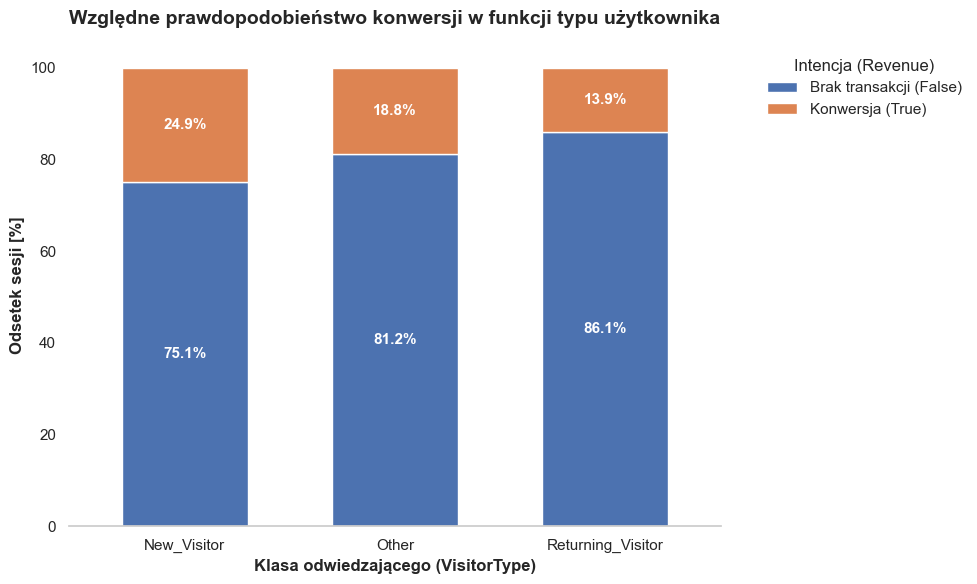

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('online_shoppers_intention.csv')

cross_tab = pd.crosstab(df['VisitorType'], df['Revenue'], normalize='index') * 100

cross_tab = cross_tab.sort_values(by=True, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

cross_tab.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=['#4C72B0', '#DD8452'], 
    edgecolor='white',
    width=0.6
)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5:
        ax.text(
            x + width/2, 
            y + height/2, 
            f'{height:.1f}%', 
            ha='center', 
            va='center', 
            color='white', 
            fontweight='bold',
            fontsize=11
        )

ax.set_title('Względne prawdopodobieństwo konwersji w funkcji typu użytkownika', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Klasa odwiedzającego (VisitorType)', fontsize=12, fontweight='bold')
ax.set_ylabel('Odsetek sesji [%]', fontsize=12, fontweight='bold')

ax.set_xticklabels(cross_tab.index, rotation=0, fontsize=11)

ax.legend(['Brak transakcji (False)', 'Konwersja (True)'], title='Intencja (Revenue)', 
          bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
# Zapis na dysk
plt.savefig('stacked_visitor.png', dpi=300, transparent=True)
plt.show()

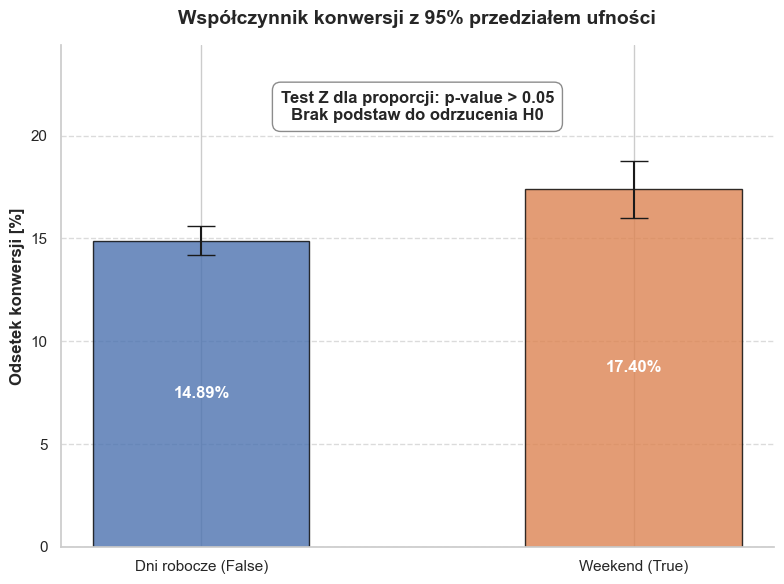

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('online_shoppers_intention.csv')

# Obliczenia statystyczne: proporcje i błędy standardowe (95% CI)
z_score = 1.96 # Krytyczna wartość Z dla poziomu ufności 95%
summary = df.groupby('Weekend')['Revenue'].agg(['mean', 'count'])
summary['se'] = np.sqrt((summary['mean'] * (1 - summary['mean'])) / summary['count'])
summary['ci'] = z_score * summary['se']

labels = ['Dni robocze (False)', 'Weekend (True)']
means = summary['mean'].values * 100
errors = summary['ci'].values * 100

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    labels, 
    means, 
    yerr=errors, 
    capsize=10, 
    color=['#4C72B0', '#DD8452'], 
    edgecolor='black',
    alpha=0.8,
    width=0.5
)

ax.text(
    0.5, 0.85, 
    "Test Z dla proporcji: p-value > 0.05\nBrak podstaw do odrzucenia H0", 
    transform=ax.transAxes, 
    fontsize=12, 
    fontweight='bold', 
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'),
    ha='center'
)

ax.set_title('Współczynnik konwersji z 95% przedziałem ufności', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Odsetek konwersji [%]', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(means + errors) * 1.3)

for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width()/2, 
        mean / 2, 
        f'{mean:.2f}%', 
        ha='center', 
        va='center', 
        color='white', 
        fontweight='bold',
        fontsize=12
    )

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# Zapis na dysk
plt.savefig('slide_11_weekend_conversion_ci.png', dpi=300, transparent=True)
plt.show()

C:\Users\janas\AppData\Local\Temp\ipykernel_31336\3749257966.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


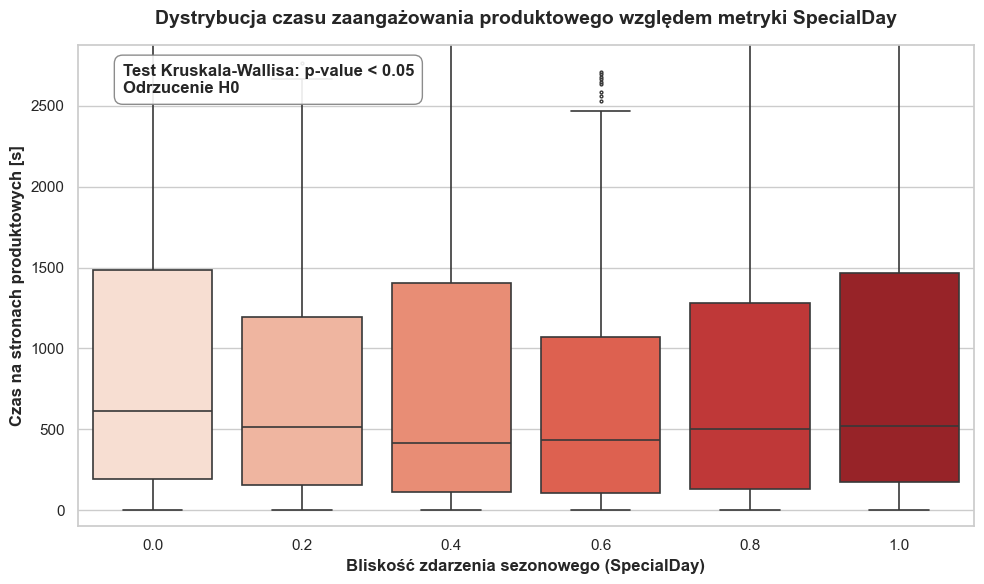

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('online_shoppers_intention.csv')

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Sortowanie unikalnych wartości SpecialDay do poprawnego wyświetlania na osi X
special_days = sorted(df['SpecialDay'].unique())

sns.boxplot(
    x='SpecialDay', 
    y='ProductRelated_Duration', 
    data=df, 
    ax=ax, 
    order=special_days,
    palette='Reds', 
    fliersize=2,   
    linewidth=1.2
)

# Optymalizacja czytelności (ograniczenie osi Y do 90. percentyla populacji)
# Zabieg ten usuwa z widoku skrajne sesje trwające np. kilkanaście godzin (często anomalie)
y_max = df['ProductRelated_Duration'].quantile(0.90)
ax.set_ylim(-100, y_max)

ax.text(
    0.05, 0.90, 
    "Test Kruskala-Wallisa: p-value < 0.05\nOdrzucenie H0", 
    transform=ax.transAxes, 
    fontsize=12, 
    fontweight='bold', 
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5')
)

ax.set_title('Dystrybucja czasu zaangażowania produktowego względem metryki SpecialDay', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bliskość zdarzenia sezonowego (SpecialDay)', fontsize=12, fontweight='bold')
ax.set_ylabel('Czas na stronach produktowych [s]', fontsize=12, fontweight='bold')

plt.tight_layout()
# Zapis na dysk
plt.savefig('boxplot_specialday.png', dpi=300, transparent=True)
plt.show()